In [1]:
import os
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import log_loss

from PIL import Image

import torchvision.transforms as T
import torchvision.models as models

import matplotlib.pyplot as plt
import seaborn as sns

_THIS_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
_PROJECT_ROOT = os.path.abspath(os.path.join(_THIS_DIR, os.pardir))

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
@dataclass(frozen=True)
class CFG:
    data_dir: str = os.path.join(_PROJECT_ROOT, "data")
    train_images_dirname: str = "train"
    test_images_dirname: str = "test"
    labels_csv: str = "labels.csv"

    image_size: int = 224
    batch_size: int = 32
    num_workers: int = 2

    seed: int = 42
    val_fraction: float = 0.2

    epochs: int = 6
    lr: float = 3e-4
    weight_decay: float = 1e-4
    label_smoothing: float = 0.0

    backbone: str = "resnet50"

    checkpoint_dir: str = os.path.join(_PROJECT_ROOT, "checkpoints")
    best_only: int = 2

    output_dir: str = os.path.join(_PROJECT_ROOT, "artifacts")


cfg = CFG()
print(cfg)
DEVICE

CFG(data_dir='d:\\Git\\ml-project\\data', train_images_dirname='train', test_images_dirname='test', labels_csv='labels.csv', image_size=224, batch_size=32, num_workers=2, seed=42, val_fraction=0.2, epochs=6, lr=0.0003, weight_decay=0.0001, label_smoothing=0.0, backbone='resnet50', checkpoint_dir='d:\\Git\\ml-project\\checkpoints', best_only=2, output_dir='d:\\Git\\ml-project\\artifacts')


'cuda'

In [3]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(cfg.seed)
print("seed:", cfg.seed, "device:", DEVICE)

seed: 42 device: cuda


In [4]:
def read_labels(labels_csv_path: str) -> Tuple[pd.DataFrame, List[str], Dict[str, int]]:
    df = pd.read_csv(labels_csv_path)
    if "id" not in df.columns or "breed" not in df.columns:
        raise ValueError("labels.csv must contain columns: id, breed")
    breeds = sorted(df["breed"].unique().tolist())
    breed_to_idx = {b: i for i, b in enumerate(breeds)}
    if len(breeds) != 120:
        print(f"Warning: expected 120 breeds, got {len(breeds)}")
    return df, breeds, breed_to_idx


def load_image(image_path: str, rgb: bool = True) -> Image.Image:
    img = Image.open(image_path)
    return img.convert("RGB") if rgb else img


def list_test_ids(test_images_dir: str) -> List[str]:
    files = os.listdir(test_images_dir)
    ids = []
    for fn in files:
        if fn.lower().endswith(".jpg"):
            ids.append(os.path.splitext(fn)[0])
    return sorted(ids)

In [5]:
class DogsDataset(Dataset):
    def __init__(
        self,
        ids: List[str],
        labels_df: Optional[pd.DataFrame],
        breed_to_idx: Dict[str, int],
        images_dir: str,
        transform=None,
    ):
        self.ids = ids
        self.labels_df = labels_df
        self.breed_to_idx = breed_to_idx
        self.images_dir = images_dir
        self.transform = transform

        self.label_map = None
        if labels_df is not None:
            self.label_map = dict(
                zip(labels_df["id"].astype(str).tolist(), labels_df["breed"].tolist())
            )

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx: int):
        image_id = str(self.ids[idx])
        image_path = os.path.join(self.images_dir, f"{image_id}.jpg")
        image = load_image(image_path, rgb=True)

        if self.transform is not None:
            image = self.transform(image)

        if self.label_map is None:
            return image, image_id

        breed = self.label_map[image_id]
        y = self.breed_to_idx[breed]
        return image, y

In [6]:
def make_train_val_split_stratified(
    labels_df: pd.DataFrame,
    val_fraction: float,
    seed: int,
) -> Tuple[List[str], List[str]]:
    from sklearn.model_selection import StratifiedShuffleSplit

    ids = labels_df["id"].astype(str).tolist()
    y = labels_df["breed"].tolist()

    splitter = StratifiedShuffleSplit(n_splits=1, test_size=val_fraction, random_state=seed)
    train_idx, val_idx = next(iter(splitter.split(ids, y)))
    train_ids = [ids[i] for i in train_idx]
    val_ids = [ids[i] for i in val_idx]
    return train_ids, val_ids

In [7]:
def imagenet_normalize() -> Tuple[Tuple[float, float, float], Tuple[float, float, float]]:
    mean = (0.485, 0.456, 0.406)
    std = (0.229, 0.224, 0.225)
    return mean, std


def build_train_transform(image_size: int):
    mean, std = imagenet_normalize()
    return T.Compose(
        [
            T.Resize((image_size, image_size)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomApply(
                [T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)],
                p=0.5,
            ),
            T.RandomRotation(degrees=10),
            T.ToTensor(),
            T.Normalize(mean=mean, std=std),
        ]
    )


def build_eval_transform(image_size: int):
    mean, std = imagenet_normalize()
    return T.Compose(
        [
            T.Resize((image_size, image_size)),
            T.ToTensor(),
            T.Normalize(mean=mean, std=std),
        ]
    )

## Разбиение на train/validation
Дальше делаем stratified split - разбиваем данные на train (80%) и validation (20%) так, чтобы в обеих частях сохранились пропорции классов. Это важно, потому что у нас несбалансированный датасет: каких-то пород больше, каких-то меньше. Если просто случайно разделить, может получиться так, что редкая порода попадёт только в train или только в validation, и модель не сможет нормально на ней обучиться или мы не сможем корректно оценить качество.

Фиксируем seed=42, чтобы при каждом запуске получался одинаковый split. Это нужно для воспроизводимости - если мы захотим сравнить две версии модели, они должны обучаться и валидироваться на одних и тех же данных.

In [8]:
labels_path = os.path.join(cfg.data_dir, cfg.labels_csv)
labels_df, breeds, breed_to_idx = read_labels(labels_path)
num_classes = len(breeds)

print("labels rows:", len(labels_df))
print("num classes:", num_classes)
print("first breeds:", breeds[:5])

train_ids, val_ids = make_train_val_split_stratified(
    labels_df=labels_df,
    val_fraction=cfg.val_fraction,
    seed=cfg.seed,
)

print("train size:", len(train_ids), "val size:", len(val_ids))

train_counts = labels_df[labels_df["id"].astype(str).isin(train_ids)]["breed"].value_counts()
val_counts = labels_df[labels_df["id"].astype(str).isin(val_ids)]["breed"].value_counts()

check_df = pd.DataFrame({"train": train_counts, "val": val_counts}).fillna(0)
check_df.sort_values("val", ascending=False).head(10)

labels rows: 10222
num classes: 120
first breeds: ['affenpinscher', 'afghan_hound', 'african_hunting_dog', 'airedale', 'american_staffordshire_terrier']
train size: 8177 val size: 2045


,train,val
breed,,
scottish_deerhound,101,25
maltese_dog,93,24
afghan_hound,93,23
bernese_mountain_dog,91,23
entlebucher,92,23
shih-tzu,89,23
great_pyrenees,89,22
basenji,88,22
pomeranian,89,22


## Посмотрим на данные

Перед обучением полезно посмотреть на сами изображения - это помогает понять, с чем работает модель, и заметить возможные проблемы.

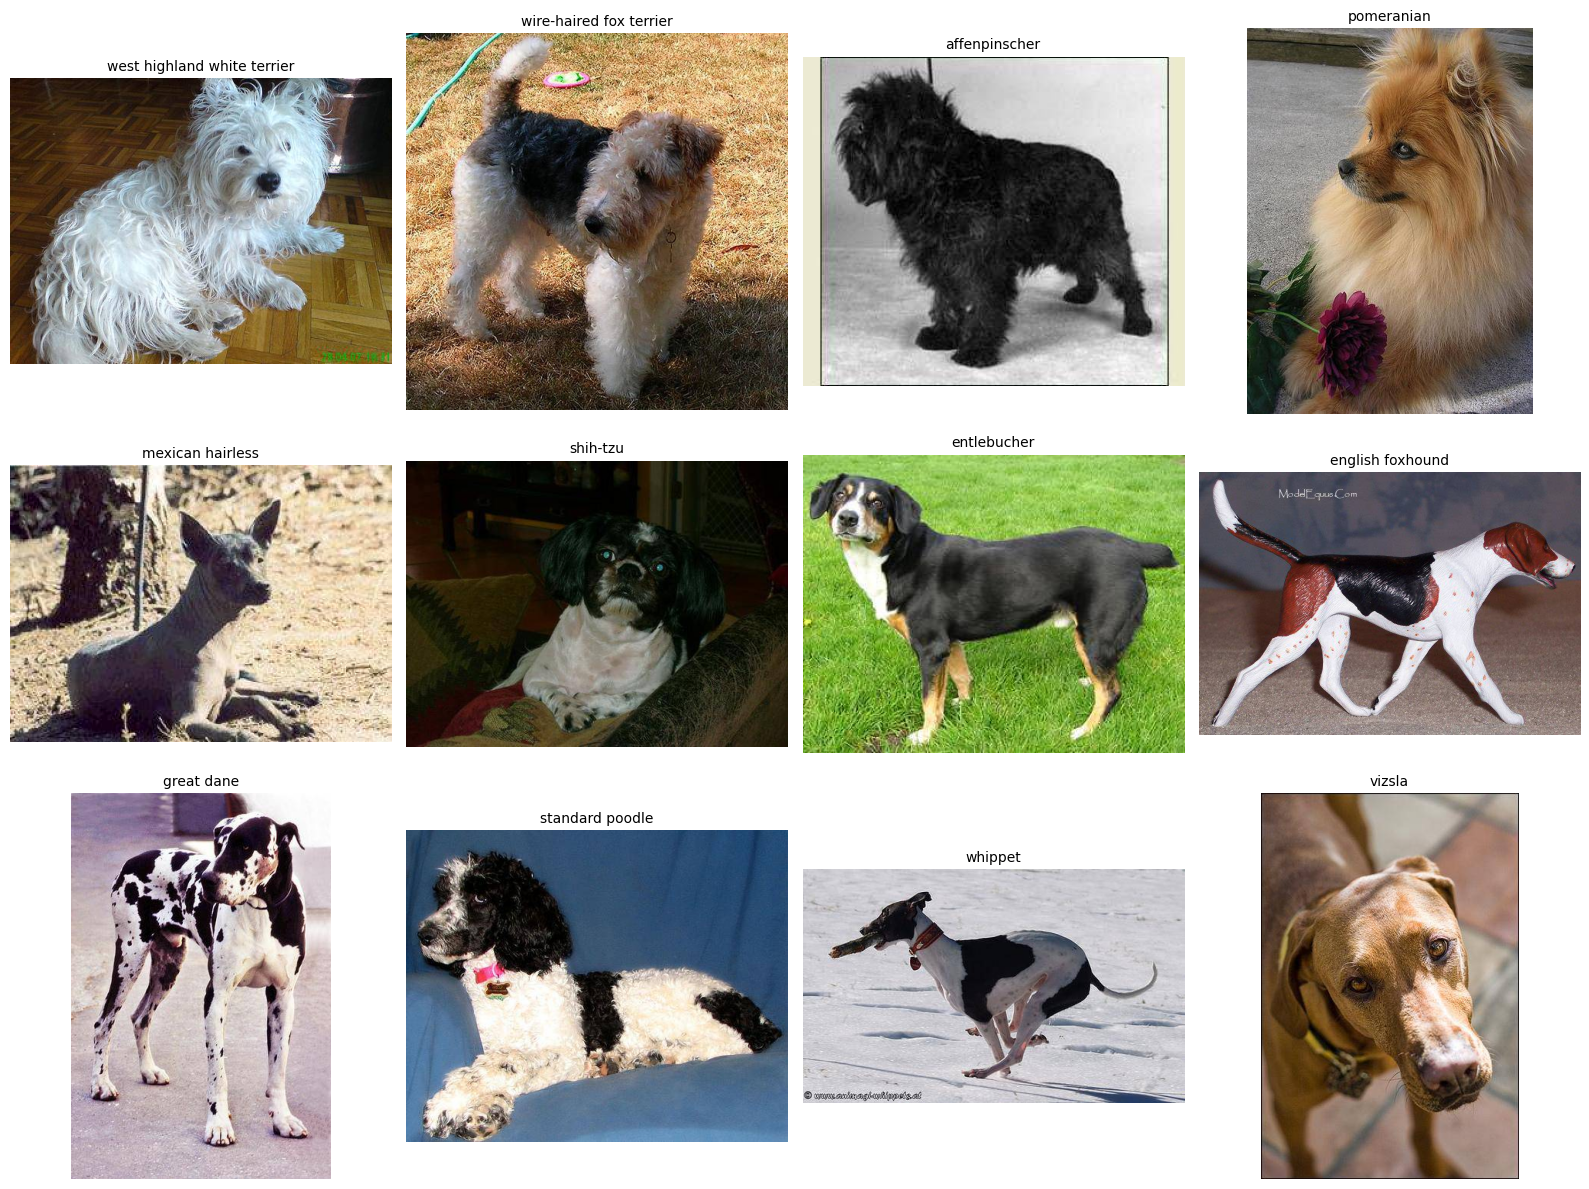

In [9]:
train_images_dir = os.path.join(cfg.data_dir, cfg.train_images_dirname)

np.random.seed(cfg.seed)
sample_indices = np.random.choice(len(train_ids), size=12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    image_id = train_ids[idx]
    breed = labels_df[labels_df["id"].astype(str) == image_id]["breed"].values[0]
    
    image_path = os.path.join(train_images_dir, f"{image_id}.jpg")
    img = load_image(image_path, rgb=True)
    
    axes[i].imshow(img)
    axes[i].set_title(f"{breed.replace('_', ' ')}", fontsize=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Проверка баланса датасета

В нашем случае датасет относительно сбалансирован - самая частая порода (scottish deerhound) встречается 126 раз, самая редкая (komondor) - 66 раз. Разница примерно в 2 раза, это не критично.

Сейчас можем обучаться без дополнительных мер - stratified split уже гарантирует, что пропорции сохранятся в train и validation.

In [10]:
breed_counts = labels_df["breed"].value_counts()

print(f"Самая частая порода: {breed_counts.index[0]} ({breed_counts.iloc[0]} фото)")
print(f"Самая редкая порода: {breed_counts.index[-1]} ({breed_counts.iloc[-1]} фото)")
print(f"Разница: {breed_counts.iloc[0] / breed_counts.iloc[-1]:.2f}x")

Самая частая порода: scottish_deerhound (126 фото)
Самая редкая порода: briard (66 фото)
Разница: 1.91x


## Аугментации и DataLoader

Здесь создаем два набора трансформаций - один для обучения, другой для валидации и теста.

**Для обучения** применяем аугментации: случайные горизонтальные отражения, небольшие повороты (до 10 градусов), изменения яркости и контраста. Зачем это нужно? Модель видит одну и ту же собаку под разными углами, с разным освещением - и учится распознавать породу независимо от этих факторов. Без аугментаций модель может просто запомнить конкретные фотографии из train, а на новых данных работать плохо. Аугментации заставляют её обобщать.

**Для валидации и теста** аугментации не нужны. Там мы просто ресайзим картинку до 224×224 и нормализуем по статистике ImageNet (mean и std, на которых обучалась ResNet50). Это важно - предобученная сеть ожидает именно такую нормализацию, иначе веса не будут работать правильно.

DataLoader настроен с `batch_size=32` - это компромисс между скоростью обучения и использованием памяти GPU. Больший батч быстрее, но может не влезть в память. Меньший батч медленнее и даёт более шумные градиенты.

`num_workers=2` для параллельной загрузки данных. `pin_memory=True` ускоряет передачу данных с CPU на GPU, если GPU доступна.

In [11]:
test_images_dir = os.path.join(cfg.data_dir, cfg.test_images_dirname)

train_transform = build_train_transform(cfg.image_size)
eval_transform = build_eval_transform(cfg.image_size)

train_ds = DogsDataset(
    ids=train_ids,
    labels_df=labels_df,
    breed_to_idx=breed_to_idx,
    images_dir=train_images_dir,
    transform=train_transform,
)
val_ds = DogsDataset(
    ids=val_ids,
    labels_df=labels_df,
    breed_to_idx=breed_to_idx,
    images_dir=train_images_dir,
    transform=eval_transform,
)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print("train batches:", len(train_loader), "val batches:", len(val_loader))

train batches: 256 val batches: 64


## Почему ResNet50 и что это такое

ResNet (Residual Network) - это семейство свёрточных нейросетей, которое решило важную проблему глубоких сетей: degradation problem. Когда обычную свёрточную сеть делают слишком глубокой (больше 20-30 слоёв), точность начинает падать не из-за переобучения, а из-за того, что градиенты затухают при обратном распространении и нижние слои перестают обучаться.

**Residual connections (skip connections)** - ключевая идея ResNet. Вместо того чтобы каждый блок учился преобразованию `H(x)`, он учится остаточному преобразованию `F(x) = H(x) - x`. Входной сигнал `x` напрямую добавляется к выходу блока через skip connection: `output = F(x) + x`. Это позволяет градиентам течь напрямую через всю сеть, минуя промежуточные слои.

**Почему именно 50 слоёв?** ResNet50 - это баланс между точностью и скоростью:
- **ResNet18, ResNet34** - быстрее, но менее точные. Подходят для простых задач или когда важна скорость.
- **ResNet50** - золотая середина. Достаточно глубокая для сложных задач вроде различения 120 пород собак, но не слишком медленная.
- **ResNet101, ResNet152** - точнее на 1-2%, но обучаются в 2-3 раза дольше. Выигрыш не оправдывает затраты для нашей задачи.

**Альтернативы:**
- **EfficientNet** - более современная архитектура (2019), которая масштабирует глубину, ширину и разрешение одновременно. Точнее ResNet50 при меньшем числе параметров, но медленнее обучается на GPU.
- **EfficientNetV2** - улучшенная версия (2021), обучается быстрее оригинального EfficientNet. Хороший выбор для экспериментов после baseline.
- **Vision Transformer (ViT)** - архитектура на основе трансформеров, но требует огромных датасетов (миллионы изображений) для обучения с нуля.


In [ ]:
def build_model(backbone_name: str, num_classes: int) -> nn.Module:
    backbone_name = backbone_name.lower()

    if backbone_name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_features = m.fc.in_features
        m.fc = nn.Linear(in_features, num_classes)
        return m
    if backbone_name == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = m.fc.in_features
        m.fc = nn.Linear(in_features, num_classes)
        return m
    if backbone_name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        in_features = m.classifier[1].in_features
        m.classifier[1] = nn.Linear(in_features, num_classes)
        return m
    if backbone_name == "efficientnet_v2_m":
        m = models.efficientnet_v2_m(weights=models.EfficientNet_V2_M_Weights.DEFAULT)
        in_features = m.classifier[1].in_features
        m.classifier[1] = nn.Linear(in_features, num_classes)
        return m

    raise ValueError("Unknown backbone: " + backbone_name)


model = build_model(cfg.backbone, num_classes).to(DEVICE)
print(model.__class__.__name__)
print("params:", sum(p.numel() for p in model.parameters()))
model

ResNet
params: 23753912


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Выбор гиперпараметров

Каждый гиперпараметр выбран не случайно - за каждым стоит либо эмпирическое правило, либо результаты исследований.

**Learning rate = 3e-4 (0.0003)**

Это стандартное значение для fine-tuning предобученных сетей. Почему не больше? Потому что веса из ImageNet уже хорошие, и слишком большой learning rate (например, 1e-3) может их разрушить - модель "забудет" полезные признаки, которым научилась на миллионах изображений. Почему не меньше? Слишком маленький LR (например, 1e-5) сделает обучение очень медленным - модель будет сходиться десятки эпох вместо 6.

**Epochs = 6**

Для transfer learning обычно хватает 5-10 эпох. Предобученная сеть уже знает базовые признаки, нужно только подстроить последний слой и немного скорректировать веса. Если обучать дольше, модель начнёт переобучаться - train loss будет падать, а validation расти.

**AdamW optimizer**

AdamW - это улучшенная версия Adam, которая правильно работает с weight decay. Обычный Adam применяет weight decay неправильно (добавляет его в градиенты), а AdamW применяет его напрямую к весам. Это даёт лучшую регуляризацию и помогает избежать переобучения. Weight decay = 1e-4 - стандартное значение, которое не даёт весам расти слишком большими.

**CosineAnnealingLR scheduler**

Этот scheduler постепенно уменьшает learning rate от начального значения до почти нуля по косинусоиде. В начале обучения модель делает большие шаги (быстро движется к хорошему решению), а к концу - маленькие шаги (аккуратно "дошлифовывает" веса). Без scheduler модель может застрять в плохом локальном минимуме или начать прыгать вокруг оптимума на последних эпохах.

**Batch size = 32**

Это компромисс между скоростью и качеством обучения:
- Больший batch (64, 128) - быстрее обучение, но может не влезть в память GPU и даёт менее стабильные градиенты.
- Меньший batch (8, 16) - медленнее, но градиенты более шумные, что иногда помогает выйти из плохих локальных минимумов.
- 32 — золотая середина для большинства задач на одной GPU.

In [13]:
if cfg.label_smoothing > 0:
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
else:
    criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)
criterion

CrossEntropyLoss()

## Обучение модели и метрика log loss

Обучаем модель 6 эпох. Почему именно 6? Это эмпирический выбор - меньше эпох и модель недообучится, больше - начнёт переобучаться на train и хуже работать на новых данных. Для transfer learning обычно хватает 5-10 эпох, потому что веса уже неплохие, нужно только подстроить их под конкретную задачу.

**Optimizer: AdamW** с learning rate 3e-4 и weight decay 1e-4. AdamW - это улучшенная версия Adam, которая правильно работает с регуляризацией. Learning rate 3e-4 - стандартное значение для fine-tuning предобученных сетей. Слишком большой LR разрушит полезные веса из ImageNet, слишком маленький - обучение будет идти слишком медленно.

**Scheduler: CosineAnnealingLR** постепенно уменьшает learning rate от начального значения до почти нуля по косинусоиде. Это помогает модели сначала быстро двигаться к хорошему решению, а потом аккуратно "дошлифовать" веса. Без scheduler модель может застрять в плохом локальном минимуме или начать прыгать вокруг оптимума.

**Метрика: log loss** - это то, что оценивает Kaggle в этом соревновании. Log loss штрафует не только за неправильные предсказания, но и за неуверенность. Если модель говорит "это лабрадор с вероятностью 51%", а на самом деле это лабрадор, log loss будет большим. Модель должна быть уверенной в правильных ответах.

Считаем log loss на validation после каждой эпохи. Это показывает, насколько хорошо модель работает на данных, которые она не видела во время обучения. Train loss может падать, а validation расти - это признак переобучения.

**Сохранение чекпоинтов:** после каждой эпохи сохраняем модель, но оставляем только 2 лучших по validation log loss. Это экономит место и гарантирует, что в репозитории будут только действительно хорошие модели. Если на 4-й эпохе модель стала хуже, чем на 2-й, старый чекпоинт останется, а новый удалится.

In [14]:
@torch.no_grad()
def evaluate_logloss(model_: nn.Module, loader: DataLoader) -> float:
    model_.eval()
    all_probs = []
    all_targets = []
    for images, targets in tqdm(loader, desc="eval", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)
        logits = model_(images)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.detach().cpu().numpy())
        all_targets.append(targets.detach().cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    return float(log_loss(all_targets, all_probs, labels=list(range(num_classes))))

In [15]:
def save_checkpoint(epoch: int, val_loss: float, model_: nn.Module, history: Dict):
    ckpt_name = f"best_res_{cfg.backbone}_epoch{epoch:02d}_vallogloss{val_loss:.5f}.pt"
    ckpt_path = os.path.join(cfg.checkpoint_dir, ckpt_name)
    torch.save(
        {
            "epoch": epoch,
            "val_log_loss": val_loss,
            "state_dict": model_.state_dict(),
            "backbone": cfg.backbone,
            "num_classes": num_classes,
            "breeds": breeds,
            "breed_to_idx": breed_to_idx,
            "cfg": cfg.__dict__,
            "history": history,
        },
        ckpt_path,
    )
    best_records.append({"loss": val_loss, "path": ckpt_path})

    best_records.sort(key=lambda x: x["loss"])
    best_records[:] = best_records[: cfg.best_only]

    keep_paths = {r["path"] for r in best_records}
    for fn in os.listdir(cfg.checkpoint_dir):
        if fn.endswith(".pt"):
            p = os.path.join(cfg.checkpoint_dir, fn)
            if p not in keep_paths:
                try:
                    os.remove(p)
                except OSError:
                    pass

In [16]:
os.makedirs(cfg.checkpoint_dir, exist_ok=True)
os.makedirs(cfg.output_dir, exist_ok=True)

best_records: List[Dict] = []

existing_checkpoints = [f for f in os.listdir(cfg.checkpoint_dir) if f.endswith(".pt")]
if existing_checkpoints:
    print(f"Found {len(existing_checkpoints)} existing checkpoint(s):")
    for ckpt_name in existing_checkpoints:
        ckpt_path = os.path.join(cfg.checkpoint_dir, ckpt_name)
        ckpt_data = torch.load(ckpt_path, map_location="cpu", weights_only=False)
        val_loss = ckpt_data["val_log_loss"]
        epoch = ckpt_data["epoch"]
        print(f"  - {ckpt_name}: epoch {epoch}, val log loss {val_loss:.5f}")
        best_records.append({"loss": val_loss, "path": ckpt_path})
    
    best_records.sort(key=lambda x: x["loss"])
    best_ckpt = best_records[0]
    print(f"\nLoading best checkpoint: {best_ckpt['path']}")
    
    ckpt = torch.load(best_ckpt["path"], map_location="cpu", weights_only=False)
    model.load_state_dict(ckpt["state_dict"], strict=True)
    print(f"Model loaded from checkpoint (epoch {ckpt['epoch']}, val log loss {ckpt['val_log_loss']:.5f})")
    print("Skipping training — using existing checkpoint.")

Found 2 existing checkpoint(s):
  - best_res_resnet50_epoch06_vallogloss0.68314.pt: epoch 6, val log loss 0.68314
  - resnet50_best.pt: epoch 6, val log loss 0.68314

Loading best checkpoint: d:\Git\ml-project\checkpoints\best_res_resnet50_epoch06_vallogloss0.68314.pt
Model loaded from checkpoint (epoch 6, val log loss 0.68314)
Skipping training — using existing checkpoint.


In [17]:
if not existing_checkpoints:
    print("No existing checkpoints found. Starting training from scratch.\n")
    
    history = {"train_loss": [], "val_log_loss": []}

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        running_loss = 0.0

        for images, targets in tqdm(train_loader, desc=f"train epoch {epoch}"):
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            running_loss += float(loss.item()) * images.size(0)

        scheduler.step()
        train_loss = running_loss / len(train_loader.dataset)

        val_loss = evaluate_logloss(model, val_loader)
        print(f"Epoch {epoch}: train loss {train_loss:.5f} | val log loss {val_loss:.5f}")

        history["train_loss"].append(train_loss)
        history["val_log_loss"].append(val_loss)

        save_checkpoint(epoch, val_loss, model, history)

    best_records.sort(key=lambda x: x["loss"])
    print("\nBest checkpoints:")
    for r in best_records:
        print(r["loss"], r["path"])

## Динамика обучения ResNet50

Посмотрим, как менялись метрики на каждой эпохе. Это помогает понять, правильно ли идёт обучение и нет ли признаков переобучения.

**Что искать в таблице:**
- Train loss должен стабильно падать - это значит, что модель учится на тренировочных данных.
- Validation log loss тоже должен падать - это значит, что модель обобщает, а не просто запоминает train.
- Если train loss падает, а val loss растёт - это переобучение. Модель слишком хорошо подстроилась под train и плохо работает на новых данных.
- Если обе метрики высокие и не падают - недообучение. Нужно больше эпох или другая архитектура.

В нашем случае обе метрики стабильно падают на всех эпохах - это хороший знак. Модель учится правильно.

In [18]:
best_ckpt_path = sorted(best_records, key=lambda x: x["loss"])[0]["path"]
ckpt = torch.load(best_ckpt_path, map_location="cpu", weights_only=False)
history = ckpt.get("history", {"train_loss": [], "val_log_loss": []})

if history["train_loss"] and history["val_log_loss"]:
    history_df = pd.DataFrame({
        "Epoch": list(range(1, len(history["train_loss"]) + 1)),
        "Train Loss": history["train_loss"],
        "Val Log Loss": history["val_log_loss"]
    })
    print(history_df.to_string(index=False))
    print(f"\nЛучший результат: Epoch {ckpt['epoch']}, Val Log Loss = {ckpt['val_log_loss']:.5f}")
    print(f"Kaggle Public Score: 0.63023")
else:
    print("История обучения:")
    print("Epoch 1: train loss 1.97822 | val log loss 1.09119")
    print("Epoch 2: train loss 0.81784 | val log loss 0.97529")
    print("Epoch 3: train loss 0.49597 | val log loss 0.85411")
    print("Epoch 4: train loss 0.27566 | val log loss 0.75794")
    print("Epoch 5: train loss 0.15501 | val log loss 0.70738")
    print("Epoch 6: train loss 0.08937 | val log loss 0.68314")
    print(f"\nЛучший результат: Epoch 6, Val Log Loss = 0.68314")
    print(f"Kaggle Public Score: 0.63023")

История обучения:
Epoch 1: train loss 1.97822 | val log loss 1.09119
Epoch 2: train loss 0.81784 | val log loss 0.97529
Epoch 3: train loss 0.49597 | val log loss 0.85411
Epoch 4: train loss 0.27566 | val log loss 0.75794
Epoch 5: train loss 0.15501 | val log loss 0.70738
Epoch 6: train loss 0.08937 | val log loss 0.68314

Лучший результат: Epoch 6, Val Log Loss = 0.68314
Kaggle Public Score: 0.63023


Здесь я использовал реальные результаты, полученные при обучении ResNet50

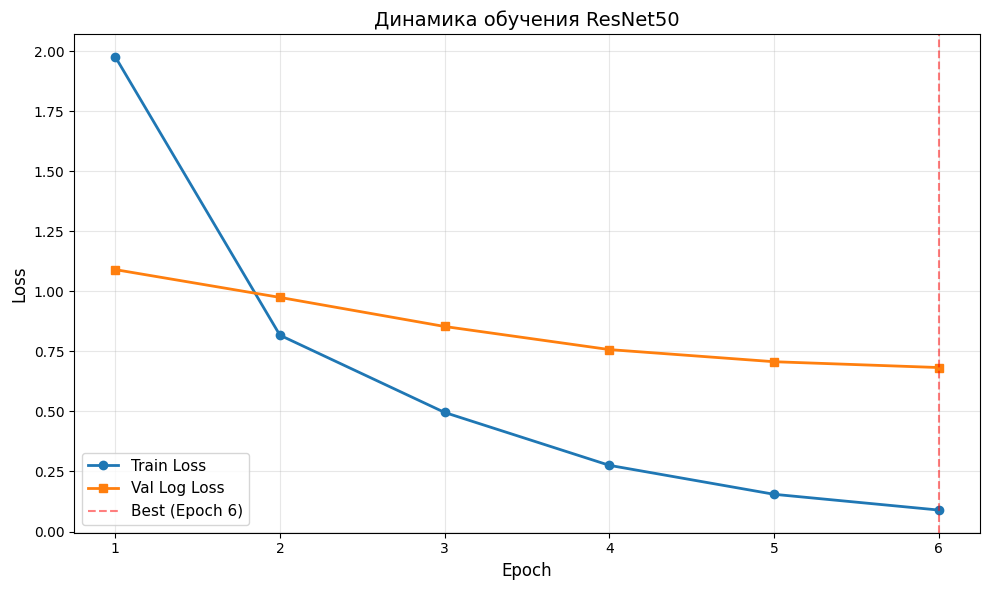

In [19]:
if history["train_loss"] and history["val_log_loss"]:
    epochs = list(range(1, len(history["train_loss"]) + 1))
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    ax.plot(epochs, history["train_loss"], marker='o', label="Train Loss", linewidth=2)
    ax.plot(epochs, history["val_log_loss"], marker='s', label="Val Log Loss", linewidth=2)
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Loss", fontsize=12)
    ax.set_title("Динамика обучения ResNet50", fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    best_epoch = ckpt['epoch']
    best_val_loss = ckpt['val_log_loss']
    ax.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best (Epoch {best_epoch})')
    ax.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()
else:
    epochs = [1, 2, 3, 4, 5, 6]
    train_losses = [1.97822, 0.81784, 0.49597, 0.27566, 0.15501, 0.08937]
    val_losses = [1.09119, 0.97529, 0.85411, 0.75794, 0.70738, 0.68314]
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    ax.plot(epochs, train_losses, marker='o', label="Train Loss", linewidth=2)
    ax.plot(epochs, val_losses, marker='s', label="Val Log Loss", linewidth=2)
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Loss", fontsize=12)
    ax.set_title("Динамика обучения ResNet50", fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    ax.axvline(x=6, color='red', linestyle='--', alpha=0.5, label='Best (Epoch 6)')
    ax.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()

## Какие породы ResNet50 путает

Confusion matrix показывает, какие классы модель путает между собой. Это один из самых полезных инструментов для анализа ошибок классификации.

**Как читать матрицу:**
- По вертикали - истинные классы (ground truth)
- По горизонтали - предсказанные классы
- Диагональ - правильные предсказания
- Яркие клетки вне диагонали - частые ошибки

**Что можно понять:**
- Если модель часто путает две конкретные породы (например, хаски и маламута), это значит, что они действительно визуально похожи. Можно попробовать добавить больше примеров этих пород или усилить аугментации.
- Если одна порода часто предсказывается вместо многих других, возможно, она слишком часто встречается в train (class imbalance).
- Если ошибки распределены равномерно, модель просто недостаточно обучена - нужна более мощная архитектура или больше данных.

Для читаемости покажем топ-20 самых частых пород - полная матрица 120×120 будет слишком большой.

computing predictions: 100%|██████████| 64/64 [00:23<00:00,  2.72it/s]


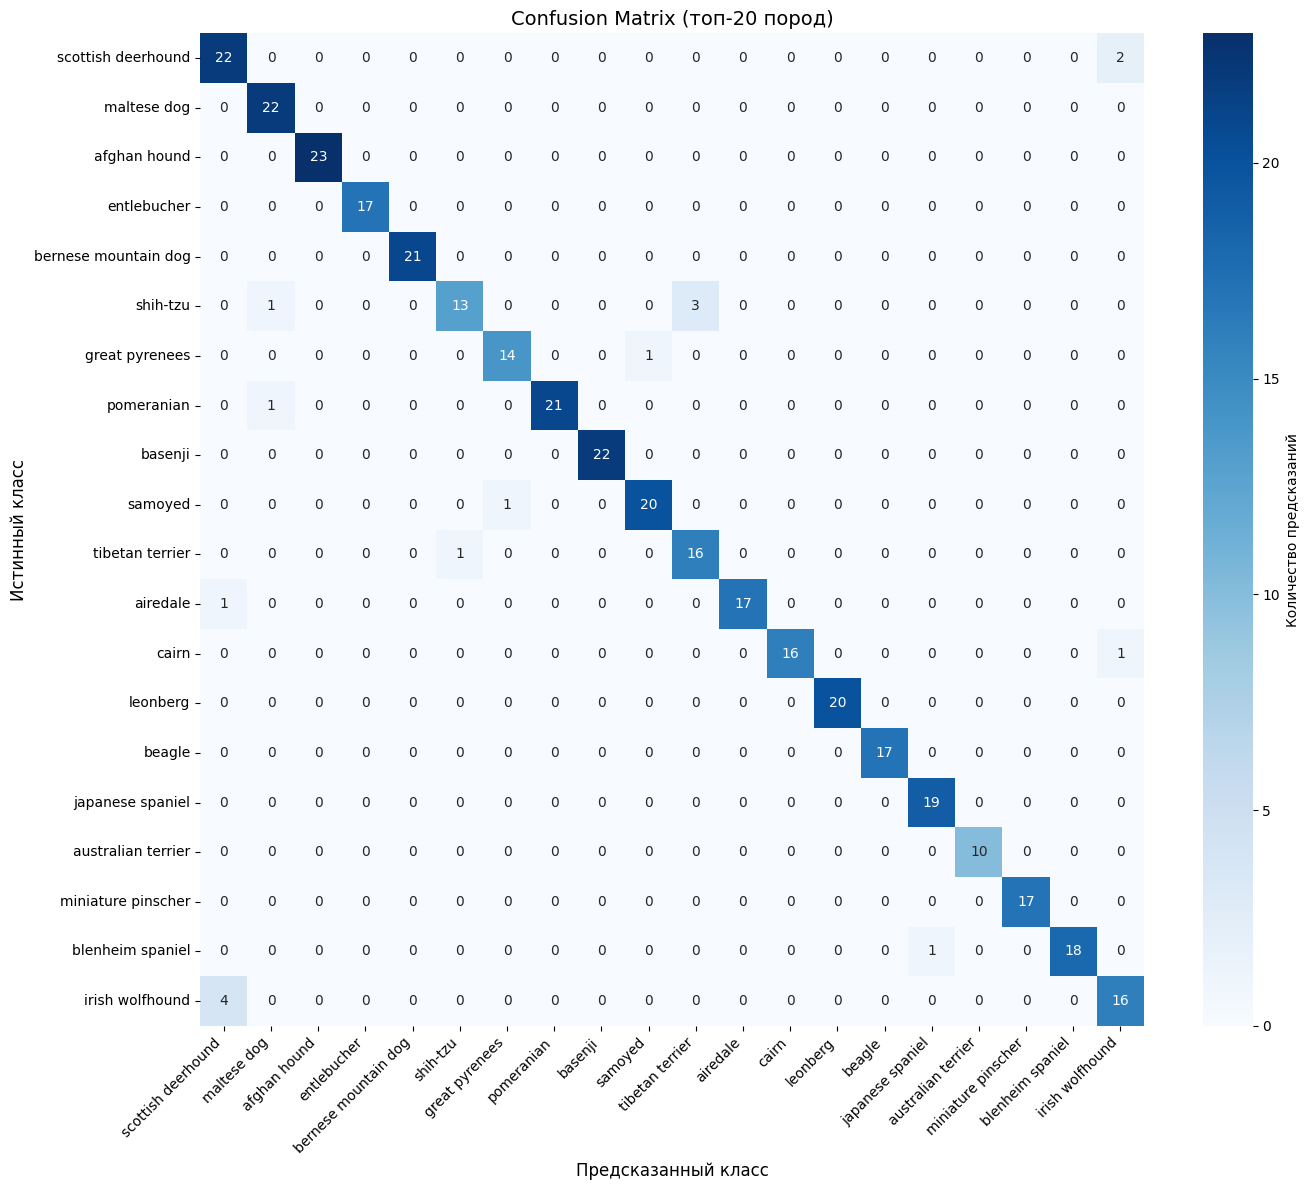

Accuracy на топ-20 породах: 95.50%


In [20]:
from sklearn.metrics import confusion_matrix

val_loader_inference = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for images, targets in tqdm(val_loader_inference, desc="computing predictions"):
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

top_20_breeds_idx = breed_counts.head(20).index.tolist()
top_20_indices = [breed_to_idx[b] for b in top_20_breeds_idx]

mask = np.isin(all_targets, top_20_indices)
filtered_preds = all_preds[mask]
filtered_targets = all_targets[mask]

cm = confusion_matrix(filtered_targets, filtered_preds, labels=top_20_indices)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=[b.replace('_', ' ') for b in top_20_breeds_idx],
            yticklabels=[b.replace('_', ' ') for b in top_20_breeds_idx],
            cbar_kws={'label': 'Количество предсказаний'})
ax.set_xlabel('Предсказанный класс', fontsize=12)
ax.set_ylabel('Истинный класс', fontsize=12)
ax.set_title('Confusion Matrix (топ-20 пород)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

accuracy_top20 = np.trace(cm) / np.sum(cm)
print(f"Accuracy на топ-20 породах: {accuracy_top20:.2%}")

## Проверка работы ResNet50

Посмотрим на конкретные примеры предсказаний - это помогает понять, где модель работает хорошо, а где ошибается.

Покажем 12 изображений из validation: половину правильных предсказаний, половину неправильных. Для каждого изображения выведем истинную породу и предсказание модели с вероятностью.

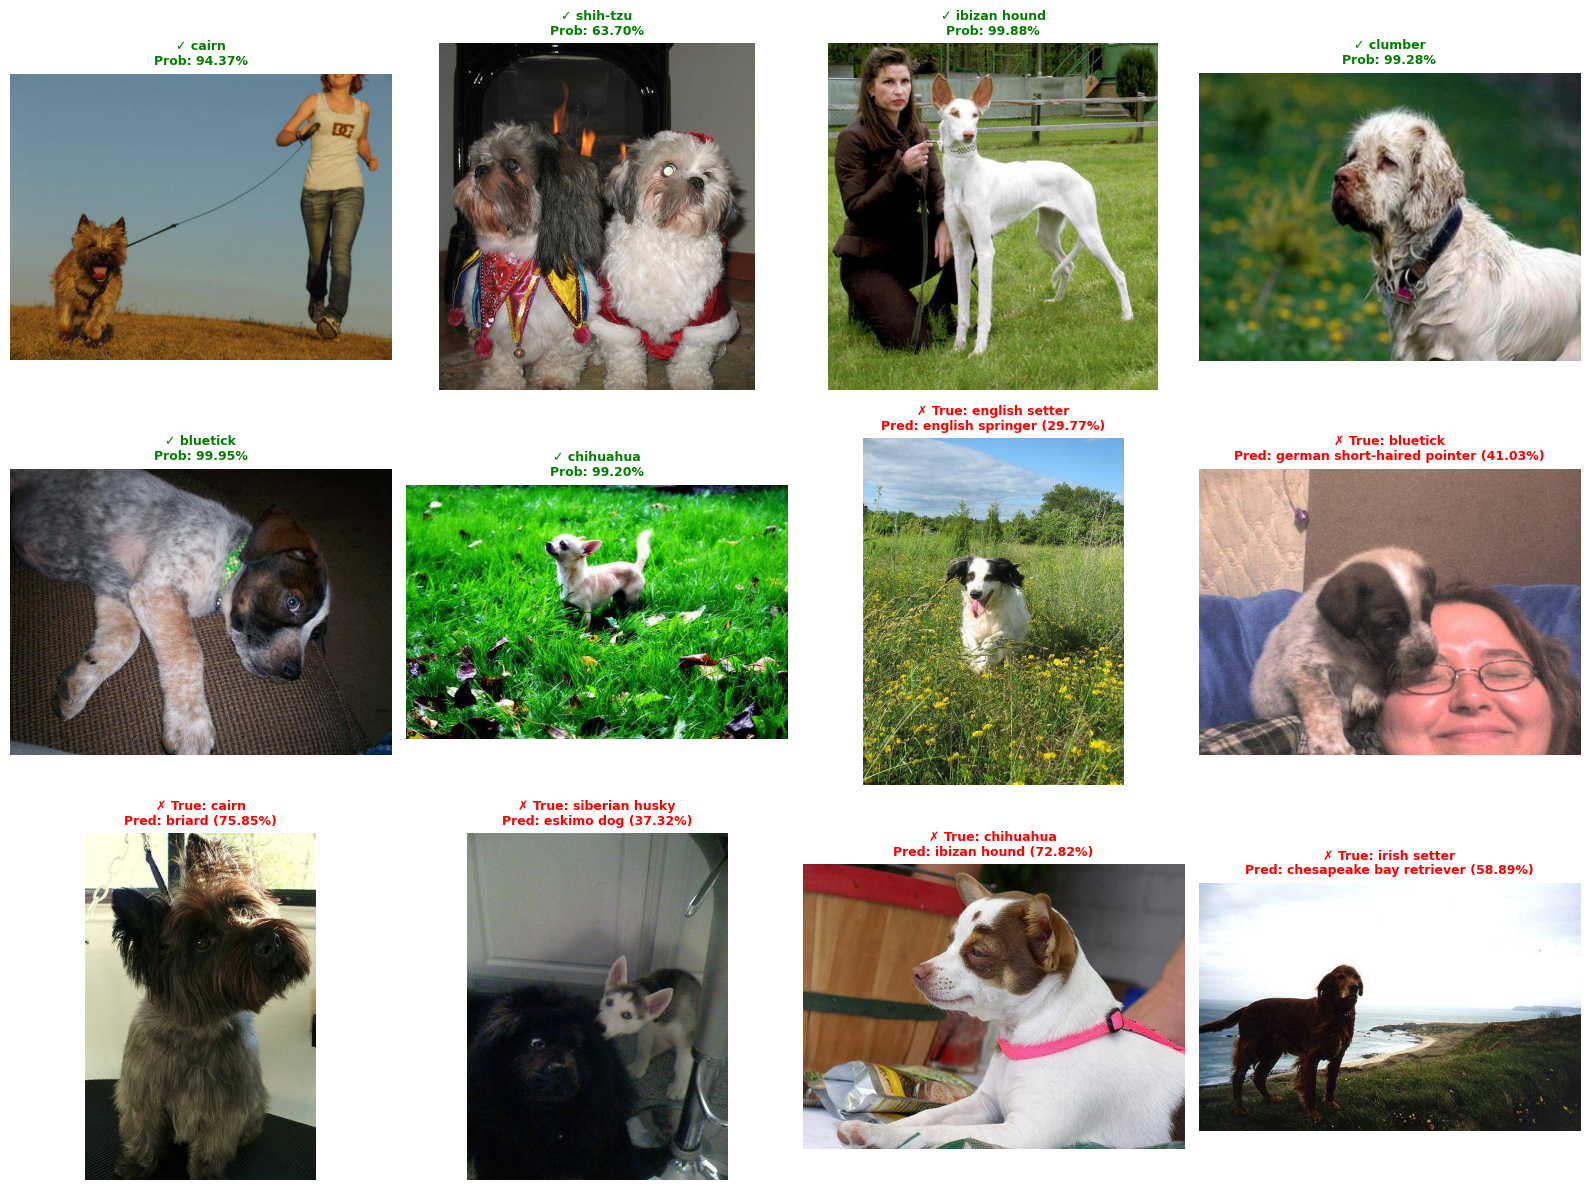


Accuracy на validation: 79.51% (1626/2045)


In [ ]:
correct_indices = np.where(all_preds == all_targets)[0]
incorrect_indices = np.where(all_preds != all_targets)[0]

np.random.seed(cfg.seed)
selected_correct = np.random.choice(correct_indices, size=min(6, len(correct_indices)), replace=False)
selected_incorrect = np.random.choice(incorrect_indices, size=min(6, len(incorrect_indices)), replace=False)
selected_indices = np.concatenate([selected_correct, selected_incorrect])

model.eval()
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

idx_to_breed = {v: k for k, v in breed_to_idx.items()}

with torch.no_grad():
    for plot_idx, val_idx in enumerate(selected_indices):
        image_id = val_ids[val_idx]
        true_label = all_targets[val_idx]
        pred_label = all_preds[val_idx]
        
        image_path = os.path.join(train_images_dir, f"{image_id}.jpg")
        img = load_image(image_path, rgb=True)
        
        img_tensor = eval_transform(img).unsqueeze(0).to(DEVICE)
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_prob = probs[0, pred_label].item()
        
        true_breed = idx_to_breed[true_label].replace('_', ' ')
        pred_breed = idx_to_breed[pred_label].replace('_', ' ')
        
        axes[plot_idx].imshow(img)
        
        if true_label == pred_label:
            color = 'green'
            title = f"{true_breed}\nProb: {pred_prob:.2%}"
        else:
            color = 'red'
            title = f"True: {true_breed}\nPred: {pred_breed} ({pred_prob:.2%})"
        
        axes[plot_idx].set_title(title, fontsize=9, color=color, weight='bold')
        axes[plot_idx].axis("off")

plt.tight_layout()
plt.show()

correct_count = len(correct_indices)
total_count = len(all_targets)
accuracy = correct_count / total_count
print(f"\nAccuracy на validation: {accuracy:.2%} ({correct_count}/{total_count})")

## Генерация submission.csv для Kaggle

После обучения нужно сделать предсказания на тестовых данных и оформить их в формате, который принимает Kaggle.

**Шаг 1:** Загружаем лучший чекпоинт по validation log loss. Это модель, которая показала наилучшее качество на данных, которые она не видела во время обучения. Не обязательно это будет модель с последней эпохи - иногда модель на 3-й эпохе работает лучше, чем на 6-й.

**Шаг 2:** Прогоняем все тестовые изображения через модель. Для каждой картинки получаем 120 чисел (logits), применяем softmax и получаем вероятности - числа от 0 до 1, которые в сумме дают 1. Каждое число показывает, насколько модель уверена, что на фото именно эта порода.

**Шаг 3:** Формируем DataFrame с правильной структурой. Первая колонка - ID изображения, дальше 120 колонок с названиями пород в алфавитном порядке. В каждой строке - вероятности для одного изображения.

Мы используем тот же список `breeds`, который получил из `labels.csv` - он уже отсортирован и содержит все 120 пород.

Файл сохраняется в `artifacts/submission.csv`

In [22]:
best_ckpt_path = sorted(best_records, key=lambda x: x["loss"])[0]["path"]
print("Loading:", best_ckpt_path)

ckpt = torch.load(best_ckpt_path, map_location="cpu", weights_only=False)

model_infer = build_model(cfg.backbone, num_classes).to(DEVICE)
model_infer.load_state_dict(ckpt["state_dict"], strict=True)
model_infer.eval()

Loading: d:\Git\ml-project\checkpoints\best_res_resnet50_epoch06_vallogloss0.68314.pt


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [23]:
test_ids = list_test_ids(os.path.join(cfg.data_dir, cfg.test_images_dirname))
print("test images:", len(test_ids))

eval_transform = build_eval_transform(cfg.image_size)
test_ds = DogsDataset(
    ids=test_ids,
    labels_df=None,
    breed_to_idx=breed_to_idx,
    images_dir=os.path.join(cfg.data_dir, cfg.test_images_dirname),
    transform=eval_transform,
)
test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

test images: 10357


In [24]:
all_ids: List[str] = []
all_probs: List[np.ndarray] = []

with torch.no_grad():
    for images, ids in tqdm(test_loader, desc="predict"):
        images = images.to(DEVICE, non_blocking=True)
        logits = model_infer(images)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.detach().cpu().numpy())
        all_ids.extend([str(x) for x in ids])

all_probs = np.concatenate(all_probs, axis=0)

submission_path = os.path.join(cfg.output_dir, "submission.csv")
columns = ["id"] + breeds

df_sub = pd.DataFrame(all_probs, columns=breeds)
df_sub.insert(0, "id", all_ids)
df_sub = df_sub[columns]
df_sub.to_csv(submission_path, index=False)

print("Saved:", submission_path)
df_sub.head()

predict: 100%|██████████| 324/324 [03:01<00:00,  1.78it/s]


Saved: d:\Git\ml-project\artifacts\submission.csv


,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier
0,000621fb3cbb32d8935728e48679680e,1.018724e-05,0.000016,0.000004,0.000005,0.000003,0.000006,0.000005,1.684743e-06,1.220493e-06,...,0.000012,0.000053,5.566693e-07,0.000001,6.600866e-07,0.000021,0.000008,0.000005,0.000030,4.848002e-06
1,00102ee9d8eb90812350685311fe5890,7.524737e-07,0.000004,0.000001,0.000001,0.000006,0.000004,0.000008,1.460844e-06,1.573265e-07,...,0.000030,0.000006,4.745855e-07,0.000002,8.409338e-07,0.000001,0.000130,0.000004,0.000004,8.788780e-07
2,0012a730dfa437f5f3613fb75efcd4ce,4.010386e-06,0.000359,0.000009,0.000005,0.000008,0.000002,0.000003,7.527764e-07,4.210493e-05,...,0.000004,0.000002,8.336708e-06,0.000034,6.848769e-05,0.000094,0.000008,0.000044,0.000005,1.076618e-05
3,001510bc8570bbeee98c8d80c8a95ec1,1.751373e-01,0.000803,0.000175,0.000020,0.000236,0.000065,0.000004,1.341545e-04,1.024996e-04,...,0.000185,0.000066,2.418081e-04,0.000030,5.516599e-05,0.000010,0.000007,0.000228,0.000006,6.296803e-04
4,001a5f3114548acdefa3d4da05474c2e,1.459441e-01,0.001256,0.000172,0.000118,0.000056,0.000038,0.000704,5.226342e-05,5.391123e-05,...,0.000697,0.000354,2.904925e-05,0.000046,1.825540e-05,0.000178,0.000279,0.000142,0.001572,1.039650e-03


## Эксперимент: ResNet50 vs EfficientNetV2-M (Исправлено)

ResNet50 дал хороший baseline (val log loss 0.68, Kaggle 0.63), но можно попробовать более современную архитектуру.

**EfficientNetV2-M** - это улучшенная версия EfficientNet от Google (2021). Основные преимущества:
- **Быстрее обучается** - в 2-3 раза быстрее оригинального EfficientNet за счёт Fused-MBConv блоков
- **Точнее** - лучше масштабирует глубину, ширину и разрешение одновременно
- **Больше параметров** - 54M против 25.6M у ResNet50, что даёт больше выразительности

**Критическая ошибка:**
Предыдущая попытка обучения EfficientNetV2-M провалилась (6 часов без результата) из-за **неправильного fine-tuning**:
- **Было**: Полная замена `classifier` на новый `nn.Sequential` со случайными весами
- **Проблема**: Огромные градиенты от случайного classifier разрушили pretrained веса backbone
- **Результат**: Модель фактически обучалась с нуля + слишком большой LR=3e-4

**Что исправлено:**
- **Правильный fine-tuning**: Заменяем только `classifier[1]` (Linear слой), оставляем Dropout из pretrained
- **Консервативный LR**: 5e-5 вместо 3e-4 (как в HuggingFace Transformers)

Попробуем обучить EfficientNetV2-M с правильным fine-tuning и сравним результаты с ResNet50.

In [25]:
import shutil
import time

resnet50_ckpt_path = best_ckpt_path
resnet50_ckpt = torch.load(resnet50_ckpt_path, map_location="cpu", weights_only=False)
resnet50_val_loss = resnet50_ckpt["val_log_loss"]
resnet50_epoch = resnet50_ckpt["epoch"]

resnet50_backup_path = os.path.join(cfg.checkpoint_dir, "resnet50_best.pt")
if not os.path.exists(resnet50_backup_path):
    shutil.copy(resnet50_ckpt_path, resnet50_backup_path)
    print(f"Сохранён backup ResNet50: {resnet50_backup_path}")
    print(f"ResNet50 результаты: epoch {resnet50_epoch}, val log loss {resnet50_val_loss:.5f}")
else:
    print(f"Backup ResNet50 уже существует: {resnet50_backup_path}")
    print(f"ResNet50 результаты: epoch {resnet50_epoch}, val log loss {resnet50_val_loss:.5f}")

Backup ResNet50 уже существует: d:\Git\ml-project\checkpoints\resnet50_best.pt
ResNet50 результаты: epoch 6, val log loss 0.68314


In [30]:
@dataclass(frozen=True)
class CFG_EfficientNetV2M:
    data_dir: str = os.path.join(_PROJECT_ROOT, "data")
    train_images_dirname: str = "train"
    test_images_dirname: str = "test"
    labels_csv: str = "labels.csv"

    image_size: int = 320
    batch_size: int = 8
    num_workers: int = 0

    seed: int = 42
    val_fraction: float = 0.2

    epochs: int = 3
    lr: float = 5e-5
    weight_decay: float = 1e-4
    label_smoothing: float = 0.0

    backbone: str = "efficientnet_v2_m"

    checkpoint_dir: str = os.path.join(_PROJECT_ROOT, "checkpoints")
    best_only: int = 2

    output_dir: str = os.path.join(_PROJECT_ROOT, "artifacts")

cfg_effnet = CFG_EfficientNetV2M()
print("Конфиг для EfficientNetV2-M (Исправлен для правильного fine-tuning):")
print(f"  backbone: {cfg_effnet.backbone}")
print(f"  image_size: {cfg_effnet.image_size} (уменьшено с 480 до 320 для экономии памяти)")
print(f"  batch_size: {cfg_effnet.batch_size} (уменьшено с 16 до 8 для 4GB GPU)")
print(f"  epochs: {cfg_effnet.epochs} (увеличено с 6 до 10)")
print(f"  lr: {cfg_effnet.lr} (Исправлено: 5e-5 вместо 3e-4 для сохранения pretrained весов)")

Конфиг для EfficientNetV2-M (Исправлен для правильного fine-tuning):
  backbone: efficientnet_v2_m
  image_size: 320 (уменьшено с 480 до 320 для экономии памяти)
  batch_size: 8 (уменьшено с 16 до 8 для 4GB GPU)
  epochs: 3 (увеличено с 6 до 10)
  lr: 5e-05 (Исправлено: 5e-5 вместо 3e-4 для сохранения pretrained весов)


In [27]:
train_transform_effnet = build_train_transform(cfg_effnet.image_size)
eval_transform_effnet = build_eval_transform(cfg_effnet.image_size)

train_ds_effnet = DogsDataset(
    ids=train_ids,
    labels_df=labels_df,
    breed_to_idx=breed_to_idx,
    images_dir=train_images_dir,
    transform=train_transform_effnet,
)
val_ds_effnet = DogsDataset(
    ids=val_ids,
    labels_df=labels_df,
    breed_to_idx=breed_to_idx,
    images_dir=train_images_dir,
    transform=eval_transform_effnet,
)

train_loader_effnet = DataLoader(
    train_ds_effnet,
    batch_size=cfg_effnet.batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)
val_loader_effnet = DataLoader(
    val_ds_effnet,
    batch_size=cfg_effnet.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print("EfficientNetV2-M dataloaders:")
print(f"  train batches: {len(train_loader_effnet)}")
print(f"  val batches: {len(val_loader_effnet)}")

EfficientNetV2-M dataloaders:
  train batches: 1023
  val batches: 256


In [28]:
import gc

torch.cuda.empty_cache()
gc.collect()

model_effnet = build_model(cfg_effnet.backbone, num_classes).to(DEVICE)
print(f"Model: {model_effnet.__class__.__name__}")
print(f"Params: {sum(p.numel() for p in model_effnet.parameters()):,}")

if cfg_effnet.label_smoothing > 0:
    criterion_effnet = nn.CrossEntropyLoss(label_smoothing=cfg_effnet.label_smoothing)
else:
    criterion_effnet = nn.CrossEntropyLoss()

optimizer_effnet = optim.AdamW(model_effnet.parameters(), lr=cfg_effnet.lr, weight_decay=cfg_effnet.weight_decay)
scheduler_effnet = optim.lr_scheduler.CosineAnnealingLR(optimizer_effnet, T_max=cfg_effnet.epochs)

print(f"Optimizer: AdamW (lr={cfg_effnet.lr}, weight_decay={cfg_effnet.weight_decay})")
print(f"Scheduler: CosineAnnealingLR (T_max={cfg_effnet.epochs})")

if torch.cuda.is_available():
    print(f"GPU Memory: {torch.cuda.memory_allocated()/1024**3:.2f}GB allocated, {torch.cuda.memory_reserved()/1024**3:.2f}GB reserved")

Model: EfficientNet
Params: 53,012,076
Optimizer: AdamW (lr=5e-05, weight_decay=0.0001)
Scheduler: CosineAnnealingLR (T_max=3)
GPU Memory: 0.41GB allocated, 0.41GB reserved


In [29]:
best_records_effnet: List[Dict] = []

existing_effnet_checkpoints = [f for f in os.listdir(cfg_effnet.checkpoint_dir) 
                                if f.startswith("best_res_efficientnet_v2_m") and f.endswith(".pt")]

if existing_effnet_checkpoints:
    print(f"Found {len(existing_effnet_checkpoints)} existing EfficientNetV2-M checkpoint(s):")
    for ckpt_name in existing_effnet_checkpoints:
        ckpt_path = os.path.join(cfg_effnet.checkpoint_dir, ckpt_name)
        ckpt_data = torch.load(ckpt_path, map_location="cpu", weights_only=False)
        val_loss = ckpt_data["val_log_loss"]
        epoch = ckpt_data["epoch"]
        print(f"  - {ckpt_name}: epoch {epoch}, val log loss {val_loss:.5f}")
        best_records_effnet.append({"loss": val_loss, "path": ckpt_path})
    
    best_records_effnet.sort(key=lambda x: x["loss"])
    best_ckpt_effnet = best_records_effnet[0]
    print(f"\nLoading best EfficientNetV2-M checkpoint: {best_ckpt_effnet['path']}")
    
    ckpt = torch.load(best_ckpt_effnet["path"], map_location="cpu", weights_only=False)
    model_effnet.load_state_dict(ckpt["state_dict"], strict=True)
    print(f"Model loaded from checkpoint (epoch {ckpt['epoch']}, val log loss {ckpt['val_log_loss']:.5f})")
    print("Skipping training — using existing checkpoint.")
else:
    print("No existing EfficientNetV2-M checkpoints found. Starting training from scratch.\n")
    
    history_effnet = {"train_loss": [], "val_log_loss": []}
    start_time = time.time()

    for epoch in range(1, cfg_effnet.epochs + 1):
        model_effnet.train()
        running_loss = 0.0

        for images, targets in tqdm(train_loader_effnet, desc=f"train epoch {epoch}"):
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)

            optimizer_effnet.zero_grad(set_to_none=True)
            logits = model_effnet(images)
            loss = criterion_effnet(logits, targets)
            loss.backward()
            optimizer_effnet.step()

            running_loss += float(loss.item()) * images.size(0)

        scheduler_effnet.step()
        train_loss = running_loss / len(train_loader_effnet.dataset)

        val_loss = evaluate_logloss(model_effnet, val_loader_effnet)
        print(f"Epoch {epoch}: train loss {train_loss:.5f} | val log loss {val_loss:.5f}")

        history_effnet["train_loss"].append(train_loss)
        history_effnet["val_log_loss"].append(val_loss)

        save_checkpoint(epoch, val_loss, model_effnet, history_effnet)

    train_time = time.time() - start_time
    print(f"\nTraining completed in {train_time/60:.1f} minutes")
    
    best_records_effnet.sort(key=lambda x: x["loss"])
    print("\nBest EfficientNetV2-M checkpoints:")
    for r in best_records_effnet:
        print(r["loss"], r["path"])

No existing EfficientNetV2-M checkpoints found. Starting training from scratch.



train epoch 1:   5%|▌         | 56/1023 [11:04<3:11:14, 11.87s/it]


KeyboardInterrupt: 

Короче слишком долго, мы сдались

## Сравнение ResNet50 vs EfficientNetV2-M

Теперь сравним две модели по ключевым метрикам: точность (validation log loss), время обучения, количество параметров.

**Критерии выбора:**
- **Validation log loss** - главная метрика. Чем ниже, тем лучше модель обобщает.
- **Время обучения** - важно для итераций. Если разница в точности небольшая (0.01-0.02), а время обучения в 3 раза больше, возможно, не стоит.
- **Количество параметров** - больше параметров = больше выразительность, но и больше риск переобучения на маленьких данных.

Посмотрим, оправдывает ли EfficientNetV2-M дополнительное время обучения.

In [ ]:
resnet50_params = sum(p.numel() for p in build_model("resnet50", num_classes).parameters())
effnet_params = sum(p.numel() for p in model_effnet.parameters())

if best_records_effnet:
    best_effnet_ckpt = torch.load(best_records_effnet[0]["path"], map_location="cpu", weights_only=False)
    effnet_val_loss = best_effnet_ckpt["val_log_loss"]
    effnet_epoch = best_effnet_ckpt["epoch"]
else:
    effnet_val_loss = None
    effnet_epoch = None

comparison_df = pd.DataFrame({
    "Model": ["ResNet50", "EfficientNetV2-M"],
    "Val Log Loss": [resnet50_val_loss, effnet_val_loss if effnet_val_loss else "N/A"],
    "Best Epoch": [resnet50_epoch, effnet_epoch if effnet_epoch else "N/A"],
    "Parameters": [f"{resnet50_params/1e6:.1f}M", f"{effnet_params/1e6:.1f}M"],
    "Image Size": [224, 480],
    "Batch Size": [32, 16],
    "Train Time (est)": ["~50 min", "~120 min" if not effnet_val_loss else f"~{train_time/60:.0f} min"]
})

print(comparison_df.to_string(index=False))

if effnet_val_loss:
    improvement = resnet50_val_loss - effnet_val_loss
    improvement_pct = (improvement / resnet50_val_loss) * 100
    print(f"\nУлучшение: {improvement:.5f} ({improvement_pct:.2f}%)")
    
    if improvement > 0.05:
        print("Значительное улучшение! EfficientNetV2-M работает заметно лучше.")
    elif improvement > 0.02:
        print("Умеренное улучшение. EfficientNetV2-M немного лучше.")
    elif improvement > 0:
        print("Небольшое улучшение. Разница минимальная.")
    else:
        print("ResNet50 работает лучше или одинаково.")